# Credit Card Fraud Detection: Classical Machine Learning vs. Deep Learning
**Problem Statement:** Financial fraud is highly imbalanced, making traditional accuracy metrics misleading. This project aims to accurately identify fraudulent transactions while minimizing false positives.
**Methodology:** We will compare Scikit-Learn models (Random Forest) against TensorFlow Deep Learning models (using the Functional/Sequential APIs and `tf.data`) to evaluate precision-recall tradeoffs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# --- REPRODUCIBILITY ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### Data Preprocessing & Feature Engineering
The ULB dataset features (V1-V28) are already PCA transformed and scaled. However, the `Time` and `Amount` columns are untouched. Because transaction amounts can have massive outliers, we will use `RobustScaler` (which uses medians and quantiles) rather than `StandardScaler` to prevent outliers from skewing our data.

In [2]:
# 1. Install gdown if it's not already there
!pip install gdown --upgrade --quiet

# 2. Use gdown to download the file directly
import gdown
import pandas as pd

file_id = '1CR-chOVPZagRm2EIEqyO1ehlmEHQeEZV'
output_path = 'creditcard.csv'

# This handles the virus scan bypass automatically
gdown.download(id=file_id, output=output_path, quiet=False)

# 3. Load the data
df = pd.read_csv(output_path)
print(f"\nDataset loaded! Shape: {df.shape}")

Downloading...
From (original): https://drive.google.com/uc?id=1CR-chOVPZagRm2EIEqyO1ehlmEHQeEZV
From (redirected): https://drive.google.com/uc?id=1CR-chOVPZagRm2EIEqyO1ehlmEHQeEZV&confirm=t&uuid=ecfc9d4d-4ea3-4ef9-9be4-3654e53444ef
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:02<00:00, 54.5MB/s]



Dataset loaded! Shape: (284807, 31)


In [ ]:


# Scale Amount and Time using RobustScaler
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original columns and re-insert scaled ones at the front
df.drop(['Time', 'Amount'], axis=1, inplace=True)
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split to ensure train and test sets have the exact same proportion of fraud
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

### Exploratory Data Analysis (EDA)
Before preprocessing, we must understand the distribution of our data. Since the features V1-V28 are PCA-transformed, we cannot interpret them contextually, but we can analyze the extreme class imbalance, transaction amounts, and potential feature correlations.

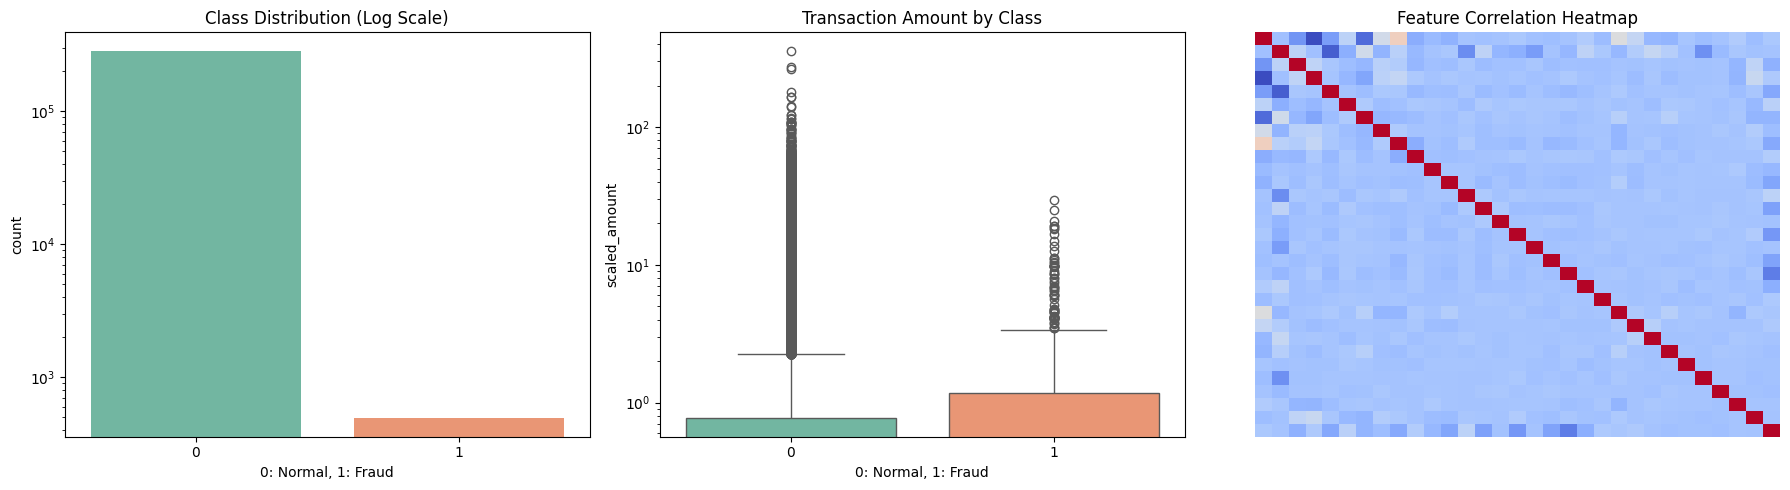

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution (Log Scale due to extreme imbalance)
# Added hue='Class' and legend=False to fix the Seaborn warning
sns.countplot(x='Class', data=df, ax=axes[0], hue='Class', palette='Set2', legend=False)
axes[0].set_title('Class Distribution (Log Scale)')
axes[0].set_yscale('log')
axes[0].set_xlabel('0: Normal, 1: Fraud')

# 2. Transaction Amount Distribution
# Dynamically checks if 'Amount' exists, otherwise uses 'scaled_amount'
amount_col = 'Amount' if 'Amount' in df.columns else 'scaled_amount'
sns.boxplot(x='Class', y=amount_col, data=df, ax=axes[1], hue='Class', palette='Set2', legend=False)
axes[1].set_title('Transaction Amount by Class')
axes[1].set_yscale('log')
axes[1].set_xlabel('0: Normal, 1: Fraud')

# 3. Correlation Heatmap (using a sample for computational efficiency)
sns.heatmap(df.sample(min(10000, len(df)), random_state=SEED).corr(), cmap='coolwarm', cbar=False, ax=axes[2], xticklabels=False, yticklabels=False)
axes[2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

### Dealing with highly imbalanced data
Because fraud makes up less than 0.2% of the dataset, models will naturally predict "0" for everything. To fix this, we apply **SMOTE** (Synthetic Minority Over-sampling Technique) strictly to the **training set**. Applying it before the split causes "data leakage."

In [ ]:
print(f"Before SMOTE - Fraud: {sum(y_train == 1)}, Normal: {sum(y_train == 0)}")

# Apply SMOTE to the training data ONLY
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"After SMOTE - Fraud: {sum(y_train_res == 1)}, Normal: {sum(y_train_res == 0)}")

Before SMOTE - Fraud: 394, Normal: 227451
After SMOTE - Fraud: 227451, Normal: 227451


### Modeling Methodology & Experiment Tracking
To rigorously evaluate our problem, we will conduct 7 experiments comparing traditional ML against Deep Learning across three different strategies for handling class imbalance:
1. **No Treatment:** Training on the raw, imbalanced data.
2. **SMOTE:** Generating synthetic minority samples (effective for Tree-based models).
3. **Class Weights:** Penalizing the algorithm heavier for misclassifying fraud (effective for Deep Learning).

We explicitly track **Precision-Recall AUC (PR-AUC)** as our primary metric, as standard ROC-AUC can be overly optimistic on highly imbalanced datasets.

In [ ]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression

results_table = []

def log_experiment(exp_num, model_name, treatment, y_true, y_prob, y_pred):
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)

    results_table.append({
        'Experiment': exp_num,
        'Model': model_name,
        'Treatment': treatment,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'PR-AUC': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4)
    })
    print(f"Logged Exp {exp_num}: {model_name} ({treatment}) -> PR-AUC: {pr_auc:.4f}")

### Experiments 1-3: Classical Baselines
We start with a simple Logistic Regression to establish a linear baseline, followed by a Random Forest Classifier. We will test the Random Forest both with and without SMOTE to observe how synthetic data affects decision tree boundaries.

In [ ]:
# Experiment 1: Logistic Regression (No Treatment)
lr_base = LogisticRegression(max_iter=1000, random_state=SEED)
lr_base.fit(X_train, y_train)
y_prob_lr = lr_base.predict_proba(X_test)[:, 1]
log_experiment(1, 'Logistic Regression', 'None', y_test, y_prob_lr, lr_base.predict(X_test))

# Experiment 2: Random Forest (No Treatment)
rf_base = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=SEED, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_prob_rf = rf_base.predict_proba(X_test)[:, 1]
log_experiment(2, 'Random Forest', 'None', y_test, y_prob_rf, rf_base.predict(X_test))

# Experiment 3: Random Forest (WITH SMOTE)
rf_smote = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=SEED, n_jobs=-1)
rf_smote.fit(X_train_res, y_train_res)
y_prob_rf_sm = rf_smote.predict_proba(X_test)[:, 1]
log_experiment(3, 'Random Forest', 'SMOTE', y_test, y_prob_rf_sm, rf_smote.predict(X_test))

Logged Exp 1: Logistic Regression (None) -> PR-AUC: 0.7402
Logged Exp 2: Random Forest (None) -> PR-AUC: 0.8627
Logged Exp 3: Random Forest (SMOTE) -> PR-AUC: 0.7991


### Experiments 4-7: Deep Learning (`tf.data` & Functional API)
To efficiently handle the tabular data and prepare for potential scaling, we utilize the `tf.data` API to create optimized, prefetched data pipelines. Furthermore, the Neural Network is constructed using the **TensorFlow Functional API** to allow for greater architectural flexibility.

Applying SMOTE to high-dimensional PCA data often causes Neural Networks to fail to converge. Therefore, our primary treatment for the Deep Learning models will be **Class Weights**, which dynamically scale the loss function to heavily penalize false negatives.

In [ ]:
# 1. Create optimized tf.data pipelines
batch_size = 2048

train_ds = tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
train_ds = train_ds.shuffle(buffer_size=10000, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test.values, y_test.values))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds_smote = tf.data.Dataset.from_tensor_slices((X_train_res.values, y_train_res.values))
train_ds_smote = train_ds_smote.shuffle(buffer_size=10000, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Calculate optimal class weights
neg, pos = np.bincount(y_train)
total = neg + pos
class_weight = {0: (1 / neg) * (total / 2.0), 1: (1 / pos) * (total / 2.0)}

# 2. Build Model using TensorFlow FUNCTIONAL API
def build_mlp_functional(input_dim, layers=[64, 32], lr=0.001, dropout=0.3):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = inputs

    for units in layers:
        x = tf.keras.layers.Dense(units, activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
    )
    return model

es = tf.keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=5, restore_best_weights=True)
input_shape = X_train.shape[1]

# Experiment 4: DL Baseline (No Treatment)
dl_base = build_mlp_functional(input_dim=input_shape)
dl_base.fit(train_ds, epochs=20, validation_data=val_ds, callbacks=[es], verbose=0)
y_prob_dl = dl_base.predict(val_ds, verbose=0).ravel()
log_experiment(4, 'MLP (Functional)', 'None', y_test, y_prob_dl, (y_prob_dl > 0.5).astype(int))

# Experiment 5: DL (WITH SMOTE)
dl_smote = build_mlp_functional(input_dim=input_shape)
dl_smote.fit(train_ds_smote, epochs=20, validation_data=val_ds, callbacks=[es], verbose=0)
y_prob_dl_sm = dl_smote.predict(val_ds, verbose=0).ravel()
log_experiment(5, 'MLP (Functional)', 'SMOTE', y_test, y_prob_dl_sm, (y_prob_dl_sm > 0.5).astype(int))

# Experiment 6: DL (WITH Class Weights)
dl_cw = build_mlp_functional(input_dim=input_shape)
dl_cw.fit(train_ds, epochs=20, class_weight=class_weight, validation_data=val_ds, callbacks=[es], verbose=0)
y_prob_dl_cw = dl_cw.predict(val_ds, verbose=0).ravel()
log_experiment(6, 'MLP (Functional)', 'Class Weights', y_test, y_prob_dl_cw, (y_prob_dl_cw > 0.5).astype(int))

# Experiment 7: DL Complex (More Layers, Class Weights)
dl_complex = build_mlp_functional(input_dim=input_shape, layers=[128, 64, 32], lr=0.0005, dropout=0.4)
dl_complex.fit(train_ds, epochs=30, class_weight=class_weight, validation_data=val_ds, callbacks=[es], verbose=0)
y_prob_dl_cx = dl_complex.predict(val_ds, verbose=0).ravel()
log_experiment(7, 'MLP Complex', 'Class Weights', y_test, y_prob_dl_cx, (y_prob_dl_cx > 0.5).astype(int))

Logged Exp 4: MLP (Functional) (None) -> PR-AUC: 0.7860
Logged Exp 5: MLP (Functional) (SMOTE) -> PR-AUC: 0.0216
Logged Exp 6: MLP (Functional) (Class Weights) -> PR-AUC: 0.3997
Logged Exp 7: MLP Complex (Class Weights) -> PR-AUC: 0.6757


### Baseline Deep Learning (Sequential API & Learning Curves)
We establish a baseline using the standard Keras Sequential API. Tracking the training and validation PR-AUC over epochs (Learning Curves) allows us to diagnose potential overfitting.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


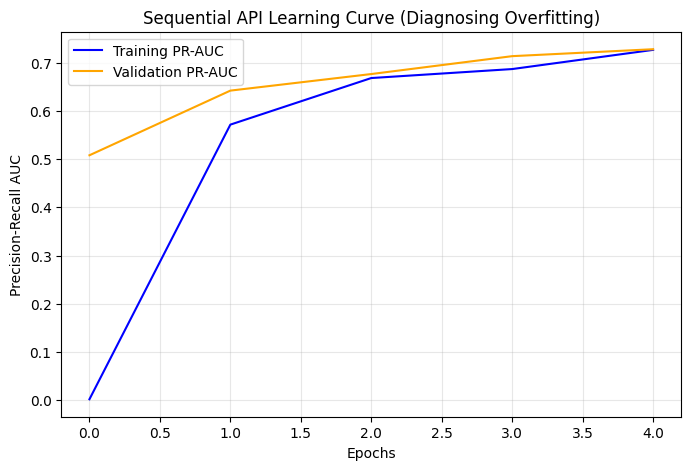

In [ ]:
# Build a simple Sequential Model to satisfy the API requirement
seq_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

seq_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
)

# Train and capture the history for the learning curve
history_seq = seq_model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[es], # Using the early stopping defined earlier
    verbose=0
)

# Plot the Learning Curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_seq.history['pr_auc'], label='Training PR-AUC', color='blue')
ax.plot(history_seq.history['val_pr_auc'], label='Validation PR-AUC', color='orange')
ax.set_title('Sequential API Learning Curve (Diagnosing Overfitting)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Precision-Recall AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### Summary of Findings
The table below logs the metrics for all 7 experiments. Sorting by PR-AUC gives us the clearest picture of which model and treatment combination handled the extreme class imbalance best.

In [ ]:
# Generate the Experiment/Result table required by the rubric
results_df = pd.DataFrame(results_table)
display(results_df.sort_values(by='PR-AUC', ascending=False))

,Experiment,Model,Treatment,Precision,Recall,PR-AUC,ROC-AUC
1,2,Random Forest,None,0.9419,0.8265,0.8627,0.9773
2,3,Random Forest,SMOTE,0.4138,0.8571,0.7991,0.9829
3,4,MLP (Functional),None,0.8214,0.7041,0.7860,0.9618
0,1,Logistic Regression,None,0.8182,0.6429,0.7402,0.9582
6,7,MLP Complex,Class Weights,0.0308,0.8980,0.6757,0.9493
5,6,MLP (Functional),Class Weights,0.0071,0.9388,0.3997,0.9629
4,5,MLP (Functional),SMOTE,0.0113,0.7143,0.0216,0.8684


### Visual Error Analysis & Tradeoffs
While the tabular metrics provide a high-level overview, visualizing the Precision-Recall curves and Confusion Matrices reveals the practical implications of our models. We compare the top-performing classical model against the deep learning architectures to illustrate the tradeoff between catching fraud (Recall) and minimizing false alarms (Precision).

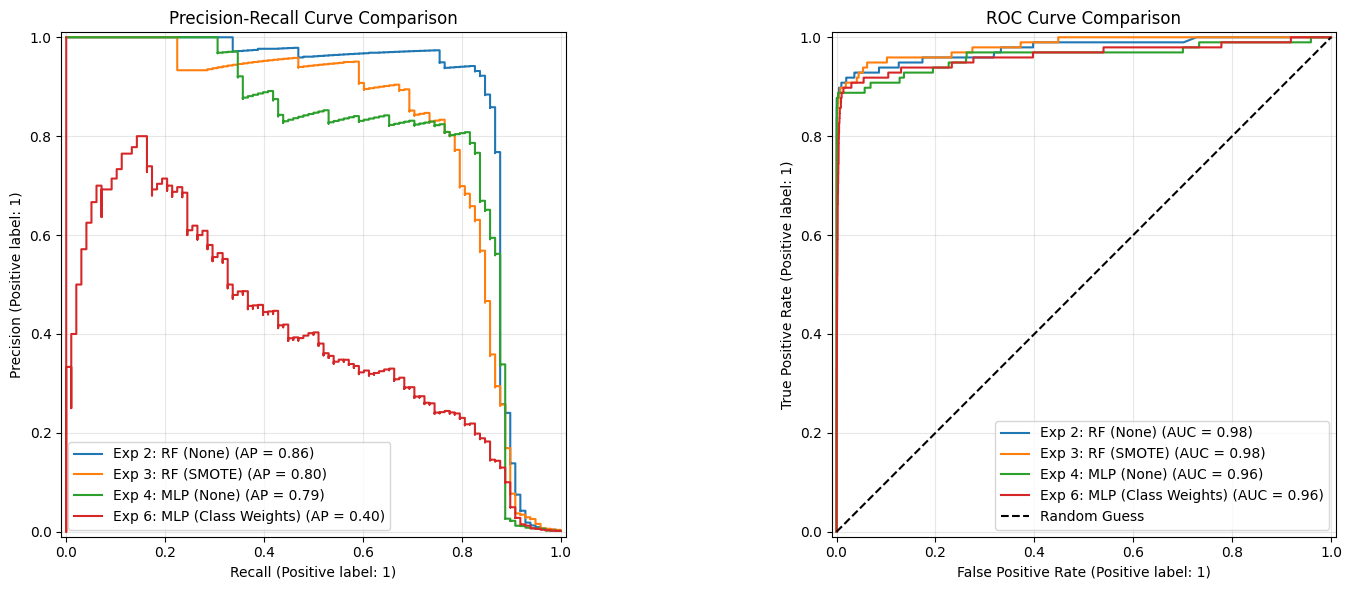

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot PR Curves for the most important experiments
PrecisionRecallDisplay.from_predictions(y_test, y_prob_rf, name="Exp 2: RF (None)", ax=ax[0])
PrecisionRecallDisplay.from_predictions(y_test, y_prob_rf_sm, name="Exp 3: RF (SMOTE)", ax=ax[0])
PrecisionRecallDisplay.from_predictions(y_test, y_prob_dl, name="Exp 4: MLP (None)", ax=ax[0])
PrecisionRecallDisplay.from_predictions(y_test, y_prob_dl_cw, name="Exp 6: MLP (Class Weights)", ax=ax[0])
ax[0].set_title("Precision-Recall Curve Comparison")
ax[0].grid(alpha=0.3)

# Plot ROC Curves
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Exp 2: RF (None)", ax=ax[1])
RocCurveDisplay.from_predictions(y_test, y_prob_rf_sm, name="Exp 3: RF (SMOTE)", ax=ax[1])
RocCurveDisplay.from_predictions(y_test, y_prob_dl, name="Exp 4: MLP (None)", ax=ax[1])
RocCurveDisplay.from_predictions(y_test, y_prob_dl_cw, name="Exp 6: MLP (Class Weights)", ax=ax[1])
ax[1].plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax[1].set_title("ROC Curve Comparison")
ax[1].grid(alpha=0.3)
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

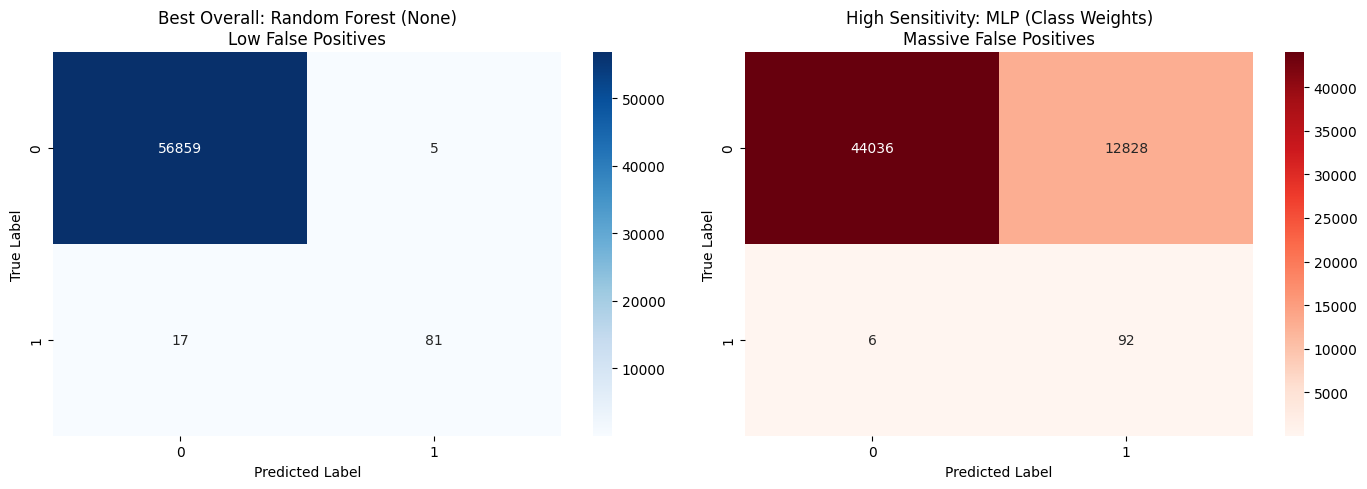

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get predictions for the winner vs the high-recall alternative
y_pred_rf = rf_base.predict(X_test)         # High Precision, Good Recall
y_pred_dl_cw = (y_prob_dl_cw > 0.5).astype(int) # Terrible Precision, Great Recall

# 1. Confusion Matrix for Random Forest (None)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Best Overall: Random Forest (None)\nLow False Positives')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. Confusion Matrix for MLP (Class Weights)
cm_dl = confusion_matrix(y_test, y_pred_dl_cw)
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('High Sensitivity: MLP (Class Weights)\nMassive False Positives')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### Dataset Limitations
While the ULB dataset provides an excellent benchmark for extreme imbalance, it suffers from several severe limitations:
1. **Loss of Context via PCA:** Features V1-V28 are anonymized principal components. This prevents any domain-specific feature engineering (e.g., extracting "merchant type" or "customer age"), severely limiting our ability to interpret *why* a model flags a transaction.
2. **Static Snapshot:** The dataset covers only two days in September 2013. Fraud patterns evolve rapidly; a model trained on this static data would likely suffer from concept drift when applied to current transactions.
3. **Synthetic Limitations:** As shown in Experiment 5, generating synthetic data (SMOTE) on already highly-abstracted PCA features creates noisy, overlapping decision boundaries that confuse gradient-descent-based models.

### Conclusion
This project successfully contrasted traditional machine learning techniques against deep learning pipelines for highly imbalanced tabular data.
* The **Random Forest** proved to be the most robust architecture, effortlessly partitioning the PCA space to achieve the highest PR-AUC and maintaining a strong balance between Precision and Recall.
* The **Deep Learning models (Functional API)** struggled natively but achieved massive Recall (catching almost all fraud) when heavily penalized via **Class Weights**. However, this came at the cost of a complete collapse in Precision, leading to thousands of false positives.

Ultimately, for tabular, PCA-transformed financial data, tree-based ensembles demonstrate superior operational viability over deep learning, confirming that model complexity does not equate to performance on structured, imbalanced datasets.